#  Performance study: NSR vs. V magnitude

### Setup notebook

In [1]:
# Alow changes to the PlatoSim code outside this notebook
%load_ext autoreload
%autoreload 2

# Configure figure in notebook
%matplotlib notebook

### Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.ticker as mticker

# PlatoSim
import platosim.plot            as pt
import platosim.utilities       as ut
import platosim.referenceFrames as rf
from platosim.lightcurve   import LightCurve
from platosim.matplotlibrc import setup_notebook
setup_notebook()

## Download data from FTP

In [3]:
# User parameters
idir = "/lhome/nicholas/data/platosimPaper/NSR_old"
idir_ref  = "/lhome/nicholas/data/platosimPaper/NSR_reference"
idir0  = "/lhome/nicholas/data/platosimPaper/NSR_jitterx1"
idir1  = "/lhome/nicholas/data/platosimPaper/NSR_jitterx3"
# idir2  = "/lhome/nicholas/data/platosimPaper/NSR_prime1x"
cfile = idir + "/starcat_all_SPF_CamVis24_NewCat_targets.ftr"

## Test example of how the NSR is calculated

In [4]:
# Load light curve object for the first star only and unpack the data
lcs = LightCurve(f"{idir}/000000001", mode="multi")
lcs.unpack()

In [15]:
# Fetch all files
filenames = lcs.files("hdf5")
filenames

['/lhome/nicholas/data/platosimPaper/NSR_old/000000001/000000001_Ncam1.1_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR_old/000000001/000000001_Ncam1.2_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR_old/000000001/000000001_Ncam1.3_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR_old/000000001/000000001_Ncam1.4_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR_old/000000001/000000001_Ncam1.5_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR_old/000000001/000000001_Ncam1.6_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR_old/000000001/000000001_Ncam2.1_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR_old/000000001/000000001_Ncam2.2_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR_old/000000001/000000001_Ncam2.3_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR_old/000000001/000000001_Ncam2.4_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR_old/000000001/000000001_Ncam2.5_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR_old/000000001/000000001_Ncam2.6_Q1.hdf5']

In [28]:
lc = LightCurve(filenames[0])

In [29]:
lc.data()
# lc.getNSR()

,time,flux_input,flux_estimated
0,12.5,425342.0,222468.724243
1,37.5,425342.0,221964.041382
2,62.5,425342.0,222818.238770
3,87.5,425342.0,222221.818359
4,112.5,425342.0,222222.646973
...,...,...,...
3451,86287.5,425342.0,222460.386475
3452,86312.5,425342.0,221879.807495
3453,86337.5,425342.0,221771.367920
3454,86362.5,425342.0,222094.194824


In [37]:
# Merge all N-CAM light curves
lc, ncam, flag = lcs.merge(quarter=1, flux_group_mean=True, suffix='hdf5')
lc.data()

,time,flux
0,6.25,1055.307447
1,12.50,-196.133853
2,31.25,-1848.289580
3,37.50,153.427639
4,56.25,200.719249
...,...,...
6907,86337.50,-118.714106
6908,86356.25,335.296296
6909,86362.50,-1021.344861
6910,86381.25,1331.100302


In [39]:
# Calculate the NSR in 1h
lc.getNSR(influx='ppm')

55.91647864908076

In [ ]:
# Show plot to verify result
lc.plot(time_unit="h", flux_unit='ppm', ncam=ncam, quarter=1, binsize=1, alpha=0.5, figsize=(9,5));

## Analysis of Merged N-CAM LCs

In [40]:
ofile = idir1 + "/results_per_star_jitterx3.ftr"

In [43]:
lcs = LightCurve(idir1, mode="multi")
lcs.run_NSRvsMag_analysis_perStar(ofile, 10000, suffix="hdf5")

  0%|                                                  | 0/10000 [00:00<?, ?it/s]                                                                                                                           


KeyError: "Unable to open object (object 'Photometry' doesn't exist)"

In [6]:
# Load results and sort logically
df = pd.read_feather(ofile)
df

,index,star,quarter,ncam,NSR,flag
0,0,1,1,12,55.916477,0
1,0,2,1,18,50.737873,0
2,0,3,1,12,41.747032,0
3,0,4,1,12,80.457657,0
4,0,5,1,6,50.640957,0
...,...,...,...,...,...,...
9475,0,9996,1,6,39.156902,0
9476,0,9997,1,6,146.576584,0
9477,0,9998,1,6,171.291107,0
9478,0,9999,1,6,70.956795,0


In [7]:
# Load input catalogue
dc = pd.read_feather(cfile)
N = len(dc)

# Merge the two data frames
mag  = np.array([])
ncon = np.array([])
for i in range(N):
    nobs = len(df[df.star == i+1])    
    mags = dc.mag.iloc[i] * np.ones(nobs)
    mag  = np.concatenate((mag, mags))
    ncons = dc.ncon.iloc[i] * np.ones(nobs)
    ncon  = np.concatenate((ncon, ncons))                
df["mag"]  = mag
df["ncon"] = ncon
df

,index,star,quarter,ncam,NSR,flag,mag,ncon
0,0,1,1,12,55.916477,0,10.618521,1.0
1,0,2,1,18,50.737873,0,10.768657,0.0
2,0,3,1,12,41.747032,0,10.060707,0.0
3,0,4,1,12,80.457657,0,11.282410,0.0
4,0,5,1,6,50.640957,0,9.783687,0.0
...,...,...,...,...,...,...,...,...
9475,0,9996,1,6,39.156902,0,9.182682,0.0
9476,0,9997,1,6,146.576584,0,11.718769,2.0
9477,0,9998,1,6,171.291107,0,12.070425,1.0
9478,0,9999,1,6,70.956795,0,10.369341,1.0


In [8]:
# Correct columns of magnitudes
df['mag'] = mag[:len(df)]
df

,index,star,quarter,ncam,NSR,flag,mag,ncon
0,0,1,1,12,55.916477,0,10.618521,1.0
1,0,2,1,18,50.737873,0,10.768657,0.0
2,0,3,1,12,41.747032,0,10.060707,0.0
3,0,4,1,12,80.457657,0,11.282410,0.0
4,0,5,1,6,50.640957,0,9.783687,0.0
...,...,...,...,...,...,...,...,...
9475,0,9996,1,6,39.156902,0,9.182682,0.0
9476,0,9997,1,6,146.576584,0,11.718769,2.0
9477,0,9998,1,6,171.291107,0,12.070425,1.0
9478,0,9999,1,6,70.956795,0,10.369341,1.0


<IPython.core.display.Javascript object>


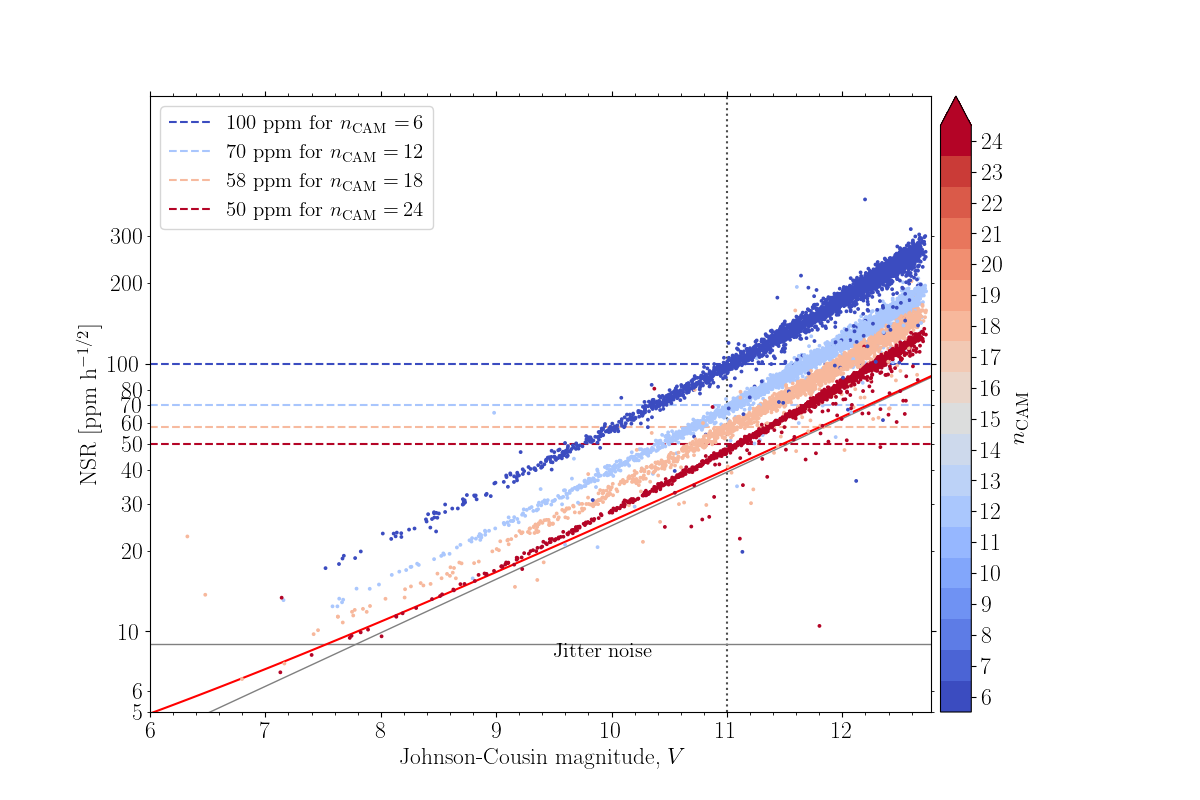

/tmp/ipykernel_521663/3555663867.py:12: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(ticks_minor)


In [14]:
# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df, column="ncam", Vmag=True, residuals="multi", 
                                legend=True, grid=False, figsize=(12,8)) #(9,8))

# Set axes limits
ax.set_xlim(6, 12.77)
ax.set_ylim(5, 1000) #340)

# We change the fontsize of minor ticks label 
ticks_minor = [5, 6, 20, 30, 40, 50, 60, 70, 80, 200, 300]
ax.yaxis.set_minor_locator(mticker.FixedLocator(ticks_minor))
ax.set_yticklabels(ticks_minor)
ticks_major = [1, 10, 100]
ax.yaxis.set_major_locator(mticker.FixedLocator(ticks_major))
ax.set_yticklabels(ticks_major)

# Save figure
fig.savefig('NSRvsV.png', bbox_inches='tight', dpi=300);

In [11]:
df.loc[(df.NSR <20) & (df.mag > 11)]

,index,star,quarter,ncam,NSR,flag,mag,ncon
6372,0,6446,1,24,10.484730,0,11.801595,1.0
9071,0,9512,1,6,19.826637,0,11.133751,2.0
9201,0,9665,1,6,3.048779,0,11.227474,5.0


## Analysis of Indiviual N-CAM LCs

In [49]:
ofile = idir + "/results_per_camera.ftr"

In [50]:
lcs = LightCurve(idir, mode="multi")
lcs.run_NSRvsMag_analysis_perCamera(ofile, 5000, suffix="hdf5")

100%|██████████████████████████████████████████████████| 5000/5000 [1:01:45<00:0


In [51]:
# Load results and sort logically
df = pd.read_feather(ofile)
df

,index,star,group,camera,quarter,mag,NSR
0,0,1,1,2,1,NaN,192.932404
1,0,1,1,3,1,NaN,194.348236
2,0,1,1,4,1,NaN,187.786652
3,0,1,1,5,1,NaN,191.741119
4,0,1,1,6,1,NaN,192.872665
...,...,...,...,...,...,...,...
59265,0,5000,4,2,1,NaN,611.494934
59266,0,5000,4,3,1,NaN,605.438477
59267,0,5000,4,4,1,NaN,592.792175
59268,0,5000,4,5,1,NaN,596.186523


In [52]:
# Load input catalogue
dc = pd.read_feather(cfile)
N = len(dc)

# Merge the two data frames
mag  = np.array([])
ncon = np.array([])
for i in range(N):
    nobs = len(df[df.star == i+1])    
    mags = dc.mag.iloc[i] * np.ones(nobs)
    mag  = np.concatenate((mag, mags))
    ncons = dc.ncon.iloc[i] * np.ones(nobs)
    ncon  = np.concatenate((ncon, ncons))                
df["mag"]  = mag
df["ncon"] = ncon
df

,index,star,group,camera,quarter,mag,NSR,ncon
0,0,1,1,2,1,10.618521,192.932404,1.0
1,0,1,1,3,1,10.618521,194.348236,1.0
2,0,1,1,4,1,10.618521,187.786652,1.0
3,0,1,1,5,1,10.618521,191.741119,1.0
4,0,1,1,6,1,10.618521,192.872665,1.0
...,...,...,...,...,...,...,...,...
59265,0,5000,4,2,1,12.584301,611.494934,0.0
59266,0,5000,4,3,1,12.584301,605.438477,0.0
59267,0,5000,4,4,1,12.584301,592.792175,0.0
59268,0,5000,4,5,1,12.584301,596.186523,0.0


In [55]:
df1 = df.loc[df.ncon == 0]

<IPython.core.display.Javascript object>


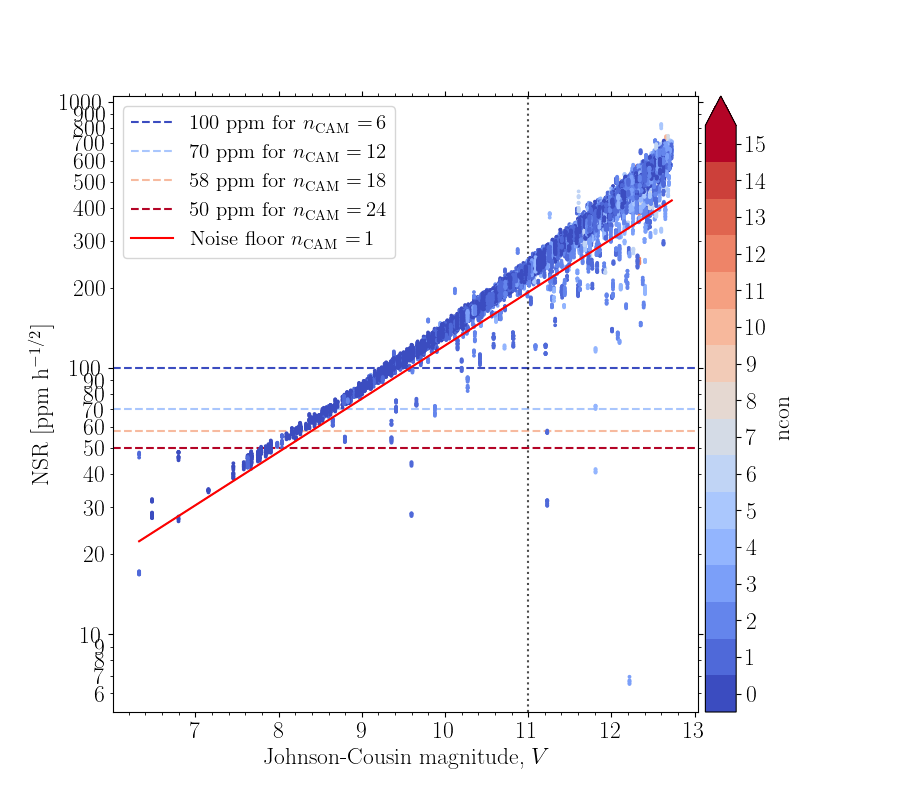

In [78]:
# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df, column="ncon", residuals="multi", passband='V',
                                noise_ncam=1, legend=True, grid=False, figsize=(9,8))

# Set axes limits
# ax.set_xlim(7, 12.77)
# ax.set_ylim(6, 340)

#### From average of N-CAMs

In [ ]:
dx = pd.DataFrame()
for i in range(1, 10001):
    star = df.loc[df["star"] == i]
    ncam = len(star)
    if ncam > 0:
        mag  = star.mag.iloc[0]
        nsr  = star.NSR.mean() / np.sqrt(ncam)
        data = {'star':i, "mag":mag, "ncam":ncam, "NSR":nsr}
        dx = dx.append(data, ignore_index=True)

In [ ]:
dx

In [ ]:
# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(dx, column="ncam", Vmag=True, residuals="multi", 
                                legend=True, grid=False, figsize=(9,8))

# Set axes limits
# ax.set_xlim(7, 12.77)
# ax.set_ylim(6, 340)

# We change the fontsize of minor ticks label 
ticks_minor = [5, 6, 20, 30, 40, 50, 60, 70, 80, 200, 300]
ax.yaxis.set_minor_locator(mticker.FixedLocator(ticks_minor))
ax.set_yticklabels(ticks_minor)
ticks_major = [1, 10, 100]
ax.yaxis.set_major_locator(mticker.FixedLocator(ticks_major))
ax.set_yticklabels(ticks_major);

# Save figure
# fig.savefig('NSRvsV.png', bbox_inches='tight', dpi=300);